In [132]:
from qiskit import QuantumCircuit
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import sys
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import math

In [126]:
n = 1

In [127]:
def circuit(seed):
    circuit = QuantumCircuit(2,2)
    circuit.h(0)
    
    circuit.rx(seed[0],0)
    circuit.rz(seed[1],0)
    circuit.ry(seed[2],0)

    circuit.cx(0,1)
    circuit.h(1)
    circuit.h(0)
    state = Statevector(circuit)
    circuit.measure([0, 1], [0, 1])
    return (state, circuit)


In [128]:
def simulation(circuit, shots):
    backend_sim = AerSimulator(method="statevector")
    sampler_sim = BackendSamplerV2(backend=backend_sim)
    
    target = backend_sim.target
    pm = generate_preset_pass_manager(target=target, optimization_level=3)
    
    qc_isa = pm.run(circuit)
    job = sampler_sim.run([qc_isa],shots=shots)
    
    res = job.result()
    return res


In [129]:

def prints_stats(res, shots):
    statistics = res[0].data.c.get_counts()
    
    for key in statistics:
        statistics[key] = float(statistics[key]) / shots
    display(plot_histogram(statistics))



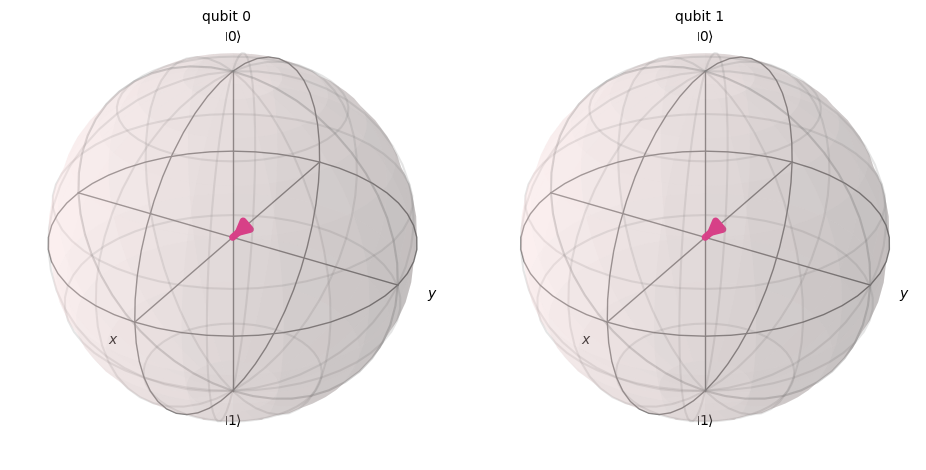

In [130]:
plot_bloch_multivector(state)


In [ ]:
step = 45

lst = []

for i in range(8):
    for j in range(8):
        for k in range(8):
            seed = [math.radians(i * 45), math.radians(j * 45), math.radians(k * 45)]
            (state, c) = circuit(seed)
            lst.append(state)
            plot_bloch_multivector(state)

#shots = 1000

      


#res = simulation(c, shots)
#prints_stats(res, shots)

#for elem in lst:
#    display(plot_bloch_multivector(elem))
    
